In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Install mediapipe (Colab usually has the rest)
!pip install mediapipe

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORTANT: Make sure your zip file is named 'isl_dataset.zip' and is in the main folder of your Google Drive.
# If you named it something else or put it in a folder, change the path below.

ZIP_FILE_PATH = '/content/drive/MyDrive/Final_Dataset.zip'
DESTINATION_DIR = '/content/'

print(f"Unzipping {ZIP_FILE_PATH} to {DESTINATION_DIR}...")
!unzip -q {ZIP_FILE_PATH} -d {DESTINATION_DIR}

print("Unzipping complete! You should now have a '/content/data' folder.")
# Check if the 'data' folder exists
!ls -l /content/

Unzipping /content/drive/MyDrive/Final_Dataset.zip to /content/...
replace /content/Final Dataset/1/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Unzipping complete! You should now have a '/content/data' folder.
total 12
drwx------  5 root root 4096 Oct 23 09:51  drive
drwxrwxrwx 37 root root 4096 Aug 25 12:48 'Final Dataset'
drwxr-xr-x  1 root root 4096 Oct 21 16:52  sample_data


In [ ]:
# === CELL 3: Data Processing Script (2-Handed) ===

import os
import cv2
import mediapipe as mp
import numpy as np
import json
import random
import math

# --- Configuration ---
# IMPORTANT: Update this path to your unzipped folder!
# Make sure this matches the output from Cell 2
DATA_DIR = '/content/Final_Dataset'
OUTPUT_NPZ = '/content/drive/MyDrive/landmark_data_2hand.npz'
LABELS_JSON = '/content/drive/MyDrive/labels_2hand.json'
AUGMENTATIONS_PER_IMAGE = 5
NUM_HANDS = 2
FEATURES_PER_HAND = 42 # 21 landmarks * 2 coords (x,y)
TOTAL_FEATURES = NUM_HANDS * FEATURES_PER_HAND # 84

# --- Augmentation Functions (Unchanged) ---
def rotate_landmarks(landmarks, angle):
    """Rotates 2D landmarks by a given angle (in degrees)."""
    angle_rad = math.radians(angle)
    cos_a = math.cos(angle_rad)
    sin_a = math.sin(angle_rad)
    rotated_landmarks = []
    for x, y in landmarks:
        x_new = x * cos_a - y * sin_a
        y_new = x * sin_a + y * cos_a
        rotated_landmarks.append((x_new, y_new))
    return rotated_landmarks

def scale_landmarks(landmarks, scale):
    """Scales 2D landmarks by a given factor."""
    return [(x * scale, y * scale) for x, y in landmarks]

def jitter_landmarks(landmarks, amount=0.01):
    """Adds small random noise to landmarks."""
    return [(x + random.uniform(-amount, amount), y + random.uniform(-amount, amount)) for x, y in landmarks]

def normalize_landmarks(landmarks_raw):
    """Normalizes landmarks to be relative to the wrist and scaled."""
    # landmarks_raw is a list of 21 (x,y) tuples
    landmarks_rel = []
    wrist_x, wrist_y = landmarks_raw[0]
    for x, y in landmarks_raw:
        landmarks_rel.append((x - wrist_x, y - wrist_y))

    max_val = max(abs(coord) for point in landmarks_rel for coord in point)
    if max_val == 0:
        return [(0.0, 0.0)] * 21
    landmarks_norm = [(x / max_val, y / max_val) for x, y in landmarks_rel]
    return landmarks_norm

# --- Main Processing Function (MODIFIED) ---
def process_data():
    # MODIFIED: Look for 2 hands
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(static_image_mode=True, max_num_hands=NUM_HANDS, min_detection_confidence=0.5)

    X_data = []
    y_labels = []
    label_map = {}

    print("Starting 2-HANDED data processing...")

    if not os.path.exists(DATA_DIR):
        print(f"ERROR: Data directory not found: {DATA_DIR}")
        return

    class_folders = sorted([f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))])
    print(f"Found {len(class_folders)} classes: {class_folders}")

    for label, class_folder in enumerate(class_folders):
        class_path = os.path.join(DATA_DIR, class_folder)
        label_map[label] = class_folder
        print(f"Processing class: {class_folder} (Assigned Label: {label})")

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            img = cv2.imread(image_path)
            if img is None: continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = hands.process(img_rgb)

            # --- MODIFIED 2-HAND LOGIC ---
            all_hands_features = []
            if results.multi_hand_landmarks:
                num_hands_detected = len(results.multi_hand_landmarks)

                # Process all detected hands (up to 2)
                for hand_landmarks in results.multi_hand_landmarks:
                    landmarks_raw = [(lm.x, lm.y) for lm in hand_landmarks.landmark]
                    landmarks_norm = normalize_landmarks(landmarks_raw)
                    all_hands_features.extend(np.array(landmarks_norm).flatten())

                # Pad with zeros if only 1 hand was detected
                if num_hands_detected < NUM_HANDS:
                    padding = [0.0] * FEATURES_PER_HAND * (NUM_HANDS - num_hands_detected)
                    all_hands_features.extend(padding)
            else:
                # No hands detected, pad with all zeros
                all_hands_features = [0.0] * TOTAL_FEATURES

            # Add the original 84-feature vector
            X_data.append(np.array(all_hands_features))
            y_labels.append(label)

            # --- AUGMENTATION (MODIFIED) ---
            # We only augment if at least one hand was found
            if results.multi_hand_landmarks:
                for _ in range(AUGMENTATIONS_PER_IMAGE):
                    augmented_features = []
                    for hand_landmarks in results.multi_hand_landmarks:
                        landmarks_raw = [(lm.x, lm.y) for lm in hand_landmarks.landmark]
                        landmarks_norm = normalize_landmarks(landmarks_raw)

                        # Apply augmentations
                        if random.random() < 0.5: landmarks_norm = rotate_landmarks(landmarks_norm, random.uniform(-15, 15))
                        if random.random() < 0.5: landmarks_norm = scale_landmarks(landmarks_norm, random.uniform(0.9, 1.1))
                        if random.random() < 0.5: landmarks_norm = jitter_landmarks(landmarks_norm, amount=0.01)

                        augmented_features.extend(np.array(landmarks_norm).flatten())

                    # Pad if needed
                    if len(results.multi_hand_landmarks) < NUM_HANDS:
                        padding = [0.0] * FEATURES_PER_HAND * (NUM_HANDS - len(results.multi_hand_landmarks))
                        augmented_features.extend(padding)

                    X_data.append(np.array(augmented_features))
                    y_labels.append(label)
            # --- END OF MODIFIED LOGIC ---

    hands.close()

    X = np.array(X_data)
    y = np.array(y_labels)

    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]

    np.savez_compressed(OUTPUT_NPZ, X=X, y=y)

    with open(LABELS_JSON, 'w') as f:
        json.dump(label_map, f, indent=4)

    print(f"\nProcessing complete! (2-Handed)")
    print(f"Total samples (with augmentations): {len(y)}")
    print(f"Data saved to: {OUTPUT_NPZ}")
    print(f"Label map saved to: {LABELS_JSON}")

process_data()


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


Starting 2-HANDED data processing...
Found 35 classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Processing class: 1 (Assigned Label: 0)
Processing class: 2 (Assigned Label: 1)
Processing class: 3 (Assigned Label: 2)
Processing class: 4 (Assigned Label: 3)
Processing class: 5 (Assigned Label: 4)
Processing class: 6 (Assigned Label: 5)
Processing class: 7 (Assigned Label: 6)
Processing class: 8 (Assigned Label: 7)
Processing class: 9 (Assigned Label: 8)
Processing class: A (Assigned Label: 9)
Processing class: B (Assigned Label: 10)
Processing class: C (Assigned Label: 11)
Processing class: D (Assigned Label: 12)
Processing class: E (Assigned Label: 13)
Processing class: F (Assigned Label: 14)
Processing class: G (Assigned Label: 15)
Processing class: H (Assigned Label: 16)
Processing class: I (Assigned Label: 17)
Processing class: J (Assigned Label: 18)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split
import json

# --- Configuration ---
# These paths must match the OUTPUT paths from Cell 3
DATA_NPZ = '/content/drive/MyDrive/landmark_data_2hand.npz'
LABELS_JSON = '/content/drive/MyDrive/labels_2hand.json'
MODEL_SAVE_PATH = '/content/drive/MyDrive/isl_model_2hand.h5'
TOTAL_FEATURES = 84 # This must match Cell 3 (21*2*2)

# 1. Load Data
print("Loading processed 2-Handed data from Google Drive...")
try:
    data = np.load(DATA_NPZ)
    X = data['X']
    y = data['y']
except FileNotFoundError:
    print(f"ERROR: File not found: {DATA_NPZ}")
    print("Please make sure Cell 3 ran successfully and created the file.")
    # Stop execution if files are missing
    raise

# 2. Load Label Map to find num_classes
try:
    with open(LABELS_JSON, 'r') as f:
        label_map = json.load(f)
    num_classes = len(label_map)
    print(f"Found {num_classes} classes.")
except FileNotFoundError:
    print(f"ERROR: File not found: {LABELS_JSON}")
    raise

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# 4. Build the Model (MODIFIED INPUT SHAPE)
model = Sequential([
    # MODIFIED: Input shape is now 84
    Input(shape=(TOTAL_FEATURES,)),

    Dense(128, activation='relu'), # Increased size for more features
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.summary()

# 5. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train the Model
print("\nStarting 2-HANDED model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    # Use EarlyStopping to prevent overfitting and stop when the model is at its best
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# 7. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy (2-Handed): {accuracy * 100:.2f}%")

# 8. Save the Model
model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")


Loading processed 2-Handed data from Google Drive...
Found 35 classes.
Training samples: 202763
Testing samples: 50691


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,315 (317.64 KB)

 Trainable params: 81,315 (317.64 KB)

 Non-trainable params: 0 (0.00 B)


Starting 2-HANDED model training...
Epoch 1/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8668 - loss: 0.4853 - val_accuracy: 0.9945 - val_loss: 0.0242
Epoch 2/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9875 - loss: 0.0473 - val_accuracy: 0.9953 - val_loss: 0.0168
Epoch 3/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9906 - loss: 0.0340 - val_accuracy: 0.9961 - val_loss: 0.0135
Epoch 4/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9917 - loss: 0.0293 - val_accuracy: 0.9967 - val_loss: 0.0118
Epoch 5/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9926 - loss: 0.0259 - val_accuracy: 0.9967 - val_loss: 0.0117
Epoch 6/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9933 - loss: 0.0248 - val_accuracy: 0.9972 - val_loss: 0.0094
Epoch 7/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9940 - loss: 0.0225 - val_accuracy: 0.9972 - val_loss: 0.0094
Epoch 8/50
6337/6337 ━━━━━━━━━━━━━━━━━━━━ 19s 


Test Accuracy (2-Handed): 99.80%
Model saved to /content/drive/MyDrive/isl_model_2hand.h5


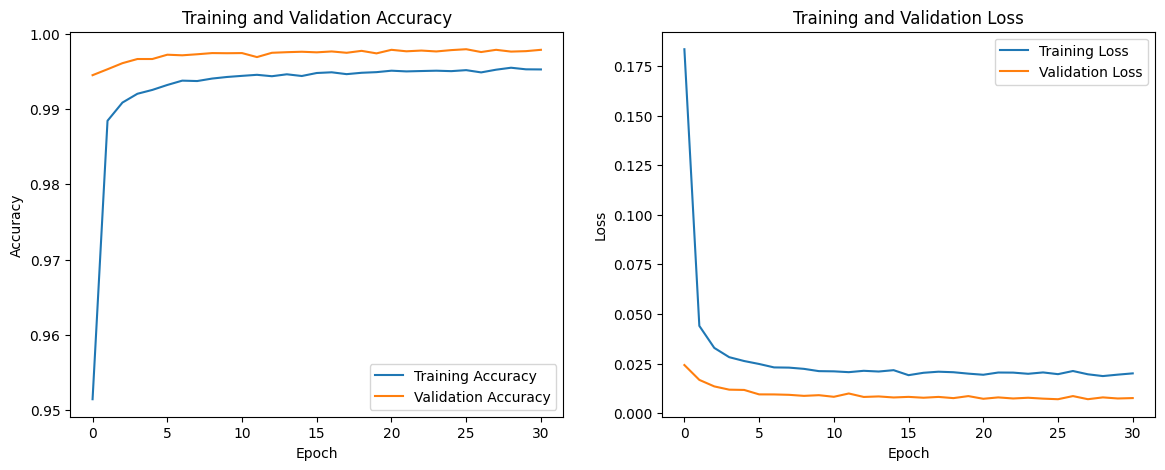

In [ ]:
import matplotlib.pyplot as plt

# --- Check if 'history' object exists ---
if 'history' not in locals():
    print("ERROR: 'history' object not found.")
    print("Please re-run Cell 4 (Model Training) before running this cell.")
else:
    # --- Get the data from the history object ---
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    # --- Create the plots ---
    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.show()
